In [2]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from tools import *

In [3]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/RBG_3_102425.csv')
df = clean_and_transpose(df, 31, 129)
df1 = df.copy()

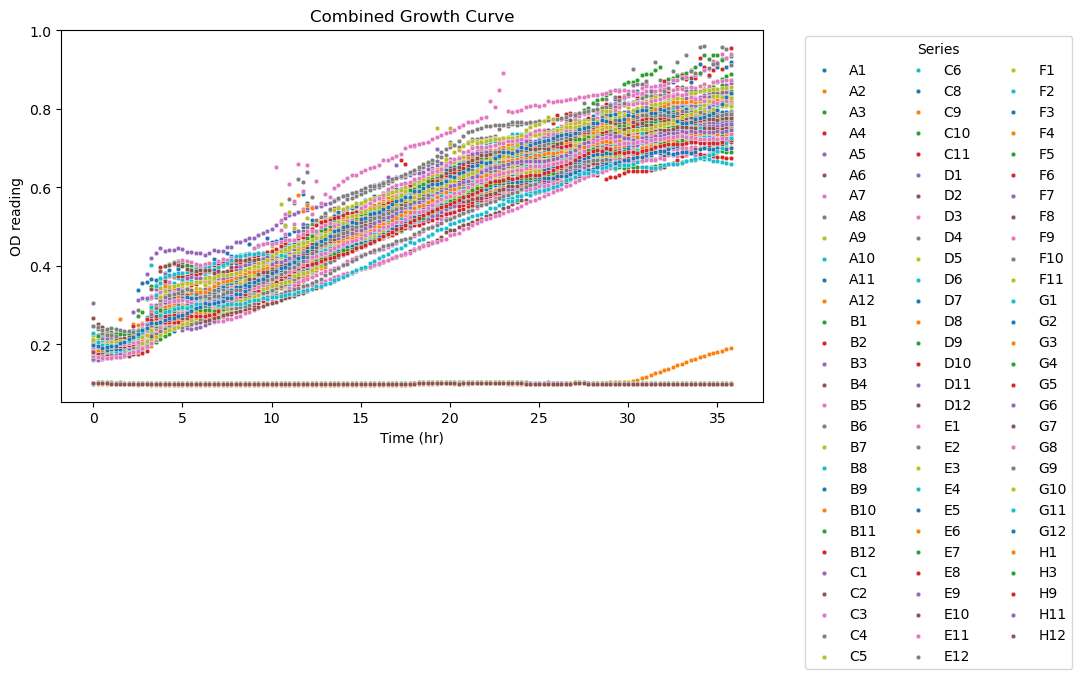

In [4]:
clean_df = remove_outliers(df1, 1, 0.10, 0.3)
plot_timeseries(clean_df, 'Combined Growth Curve')

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


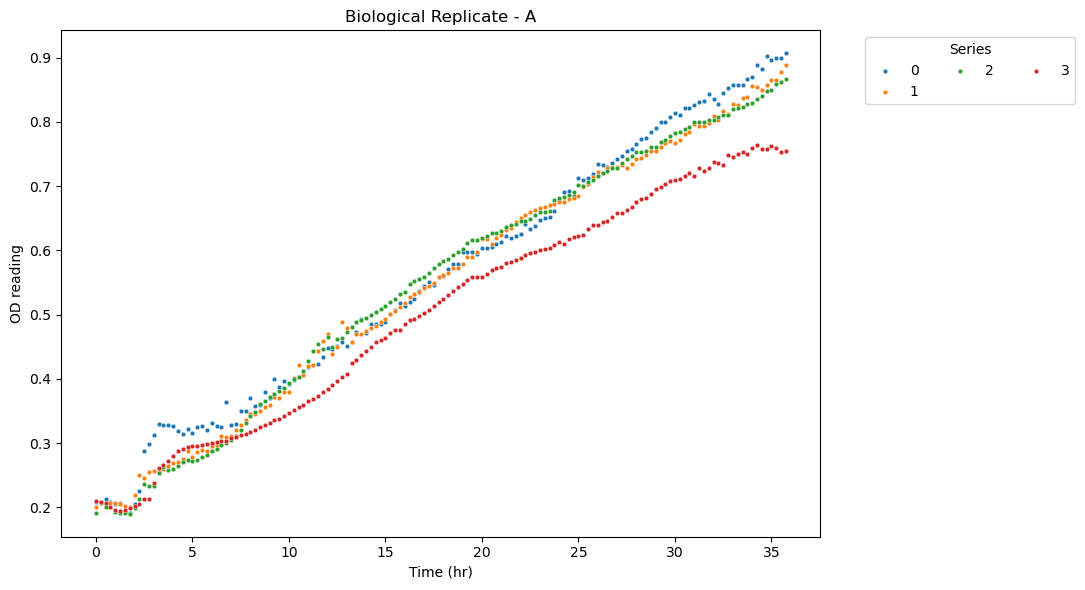

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


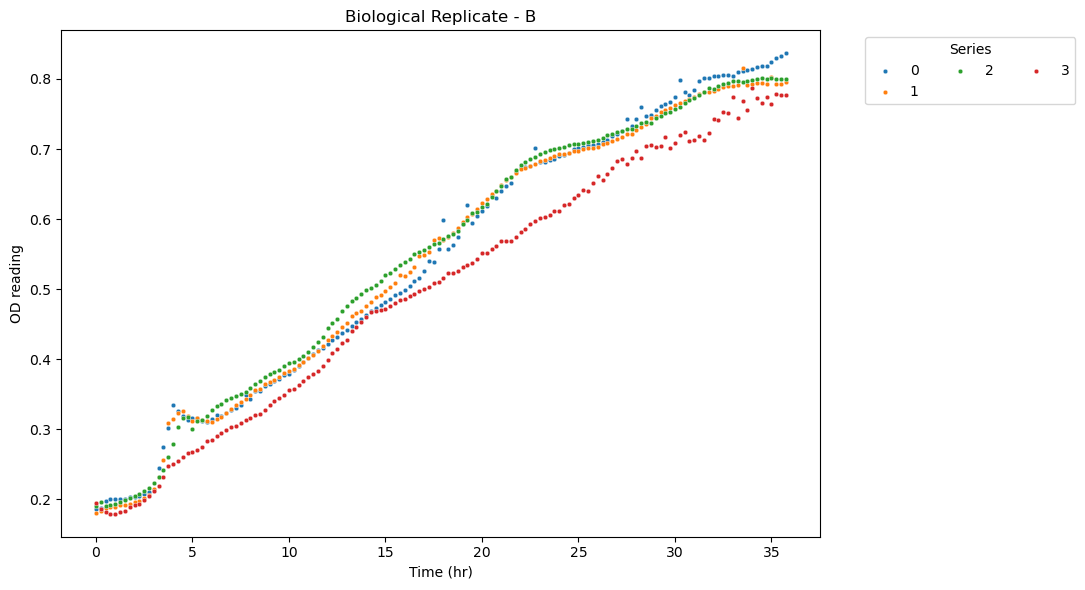

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


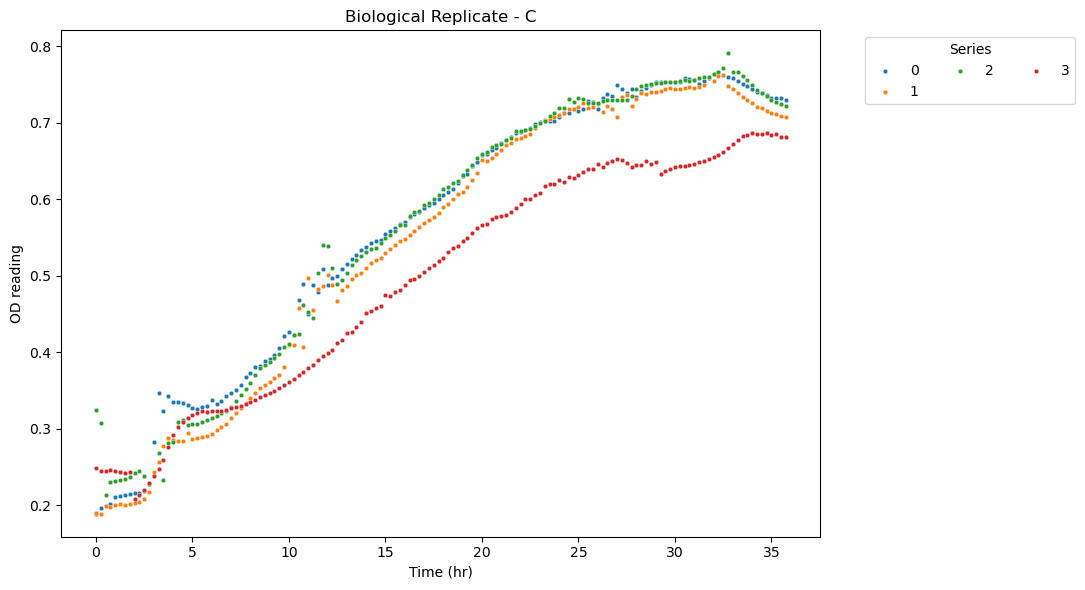

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


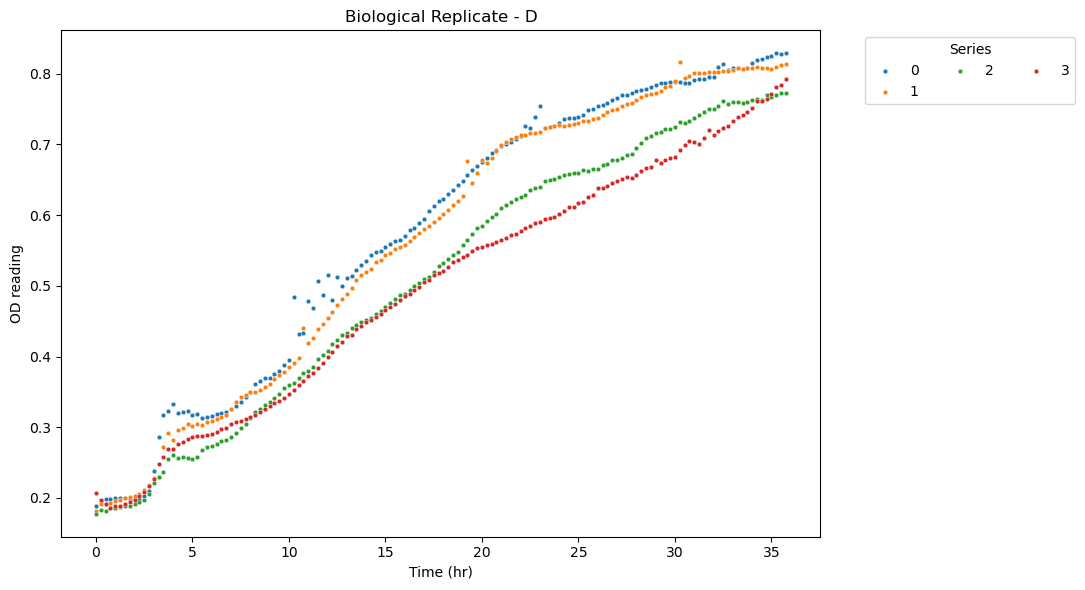

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


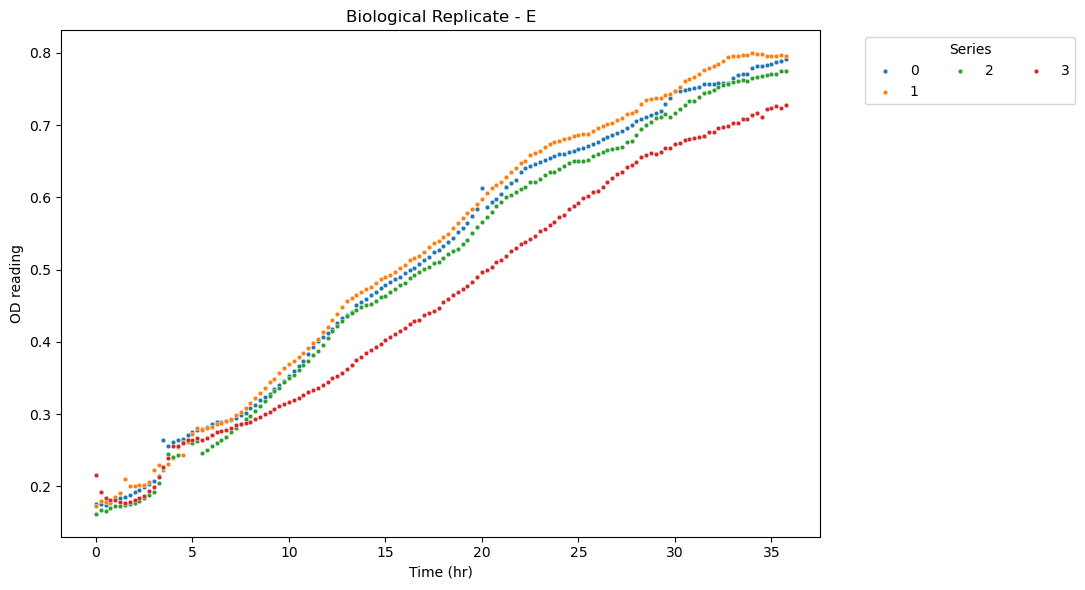

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


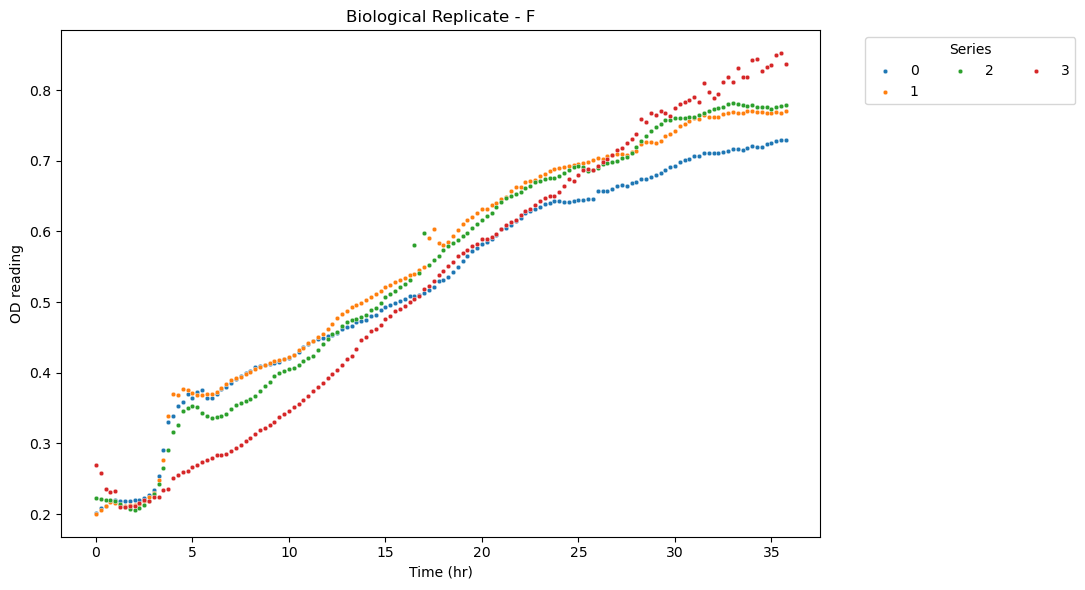

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


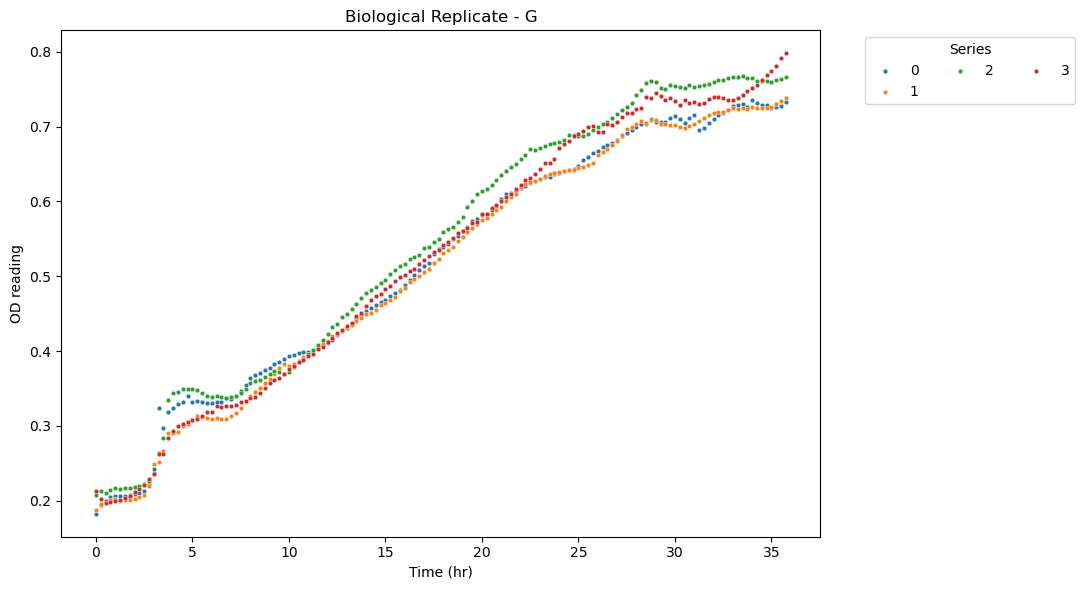

/Users/kellyhui/koskella_lab_notebook/tools.py:77: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  table_avg = table.groupby(np.arange(table.shape[1]) // col_num, axis = 1).mean()


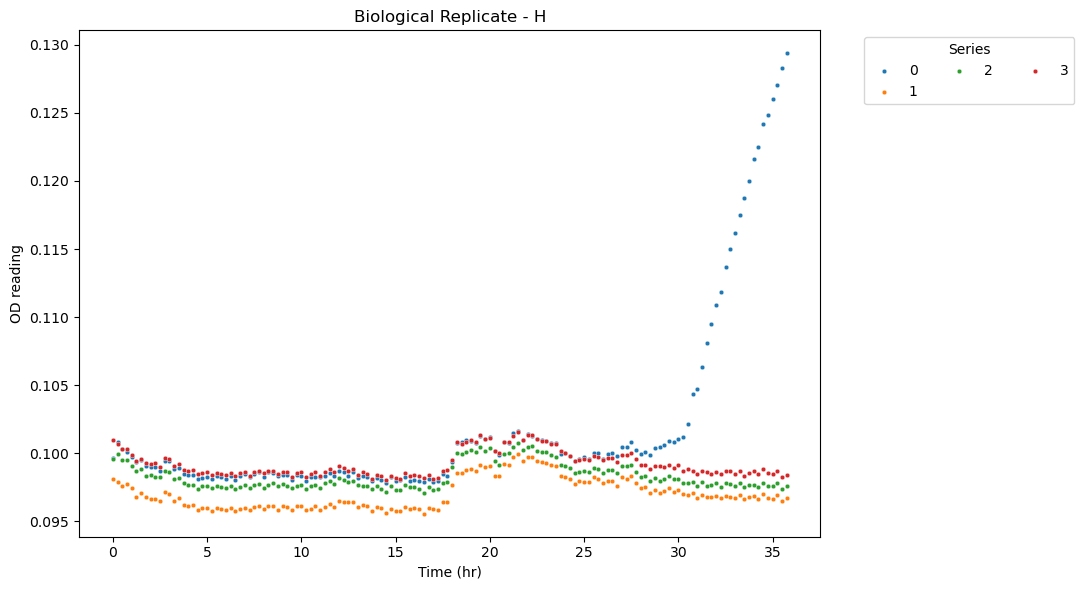

In [5]:
plot_biol_rep(df, num_bio_rep=8, col_num=3)

In [6]:
def plot_dose_response(df, pfu, num_tech_reps=3):
    df.index = pd.to_numeric(df.index, errors="coerce")
    df = df[np.isfinite(df.index)]
    df.index = np.round(df.index).astype(int)

    df_hourly = df.loc[df.index.isin(range(0, 18))]
    df_hourly = df_hourly.groupby(df_hourly.index).first()

    x_vals = [0 if p == 0 else np.log10(p) for p in pfu]

    bio_reps = list(string.ascii_uppercase)[:df_hourly.shape[1] // num_tech_reps]

    rep_tables = {
        letter: df_hourly.filter(regex=rf'^{letter}')
        for letter in bio_reps
    }

    control_table = rep_tables['H']
    
    control_avg = pd.DataFrame({
        i: control_table.iloc[:, i*num_tech_reps:(i+1)*num_tech_reps].mean(axis=1)
        for i in range(len(pfu))
    })

    for hour in df_hourly.index:
        plt.figure(figsize=(8, 6))

        control_vals = control_avg.loc[hour].values

        for letter, table in rep_tables.items():
            if table.empty:
                continue

            # Average technical replicates per dose
            table_avg = pd.DataFrame({
                i: table.iloc[:, i*num_tech_reps:(i+1)*num_tech_reps].mean(axis=1)
                for i in range(len(pfu))
            })
            corrected_vals = table_avg.loc[hour].values - control_vals

            plt.plot(x_vals, corrected_vals, marker='o', label=letter)

        plt.xlabel('log10(PFU)')
        plt.ylabel('OD₅₀')
        plt.title(f'OD₅₀ vs log(PFU) at Hour {hour}')
        plt.legend(title='Biological Replicates', bbox_to_anchor=(1.05, 1))
        plt.grid(True)


In [7]:
pfu_values = [0, 1e3, 1e5, 1e7]

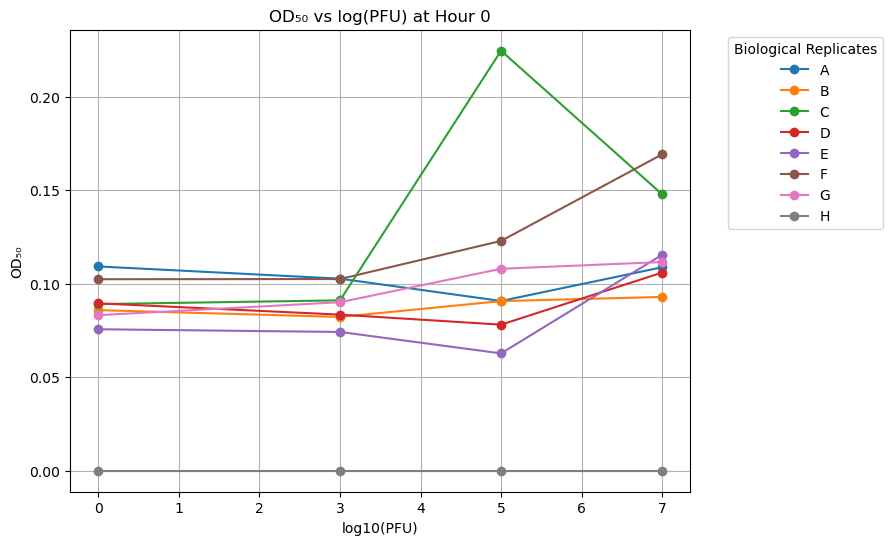

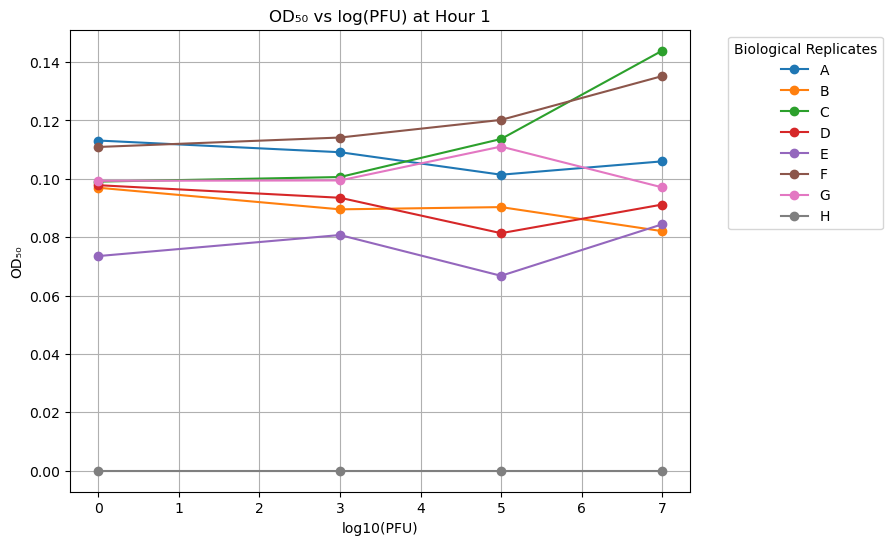

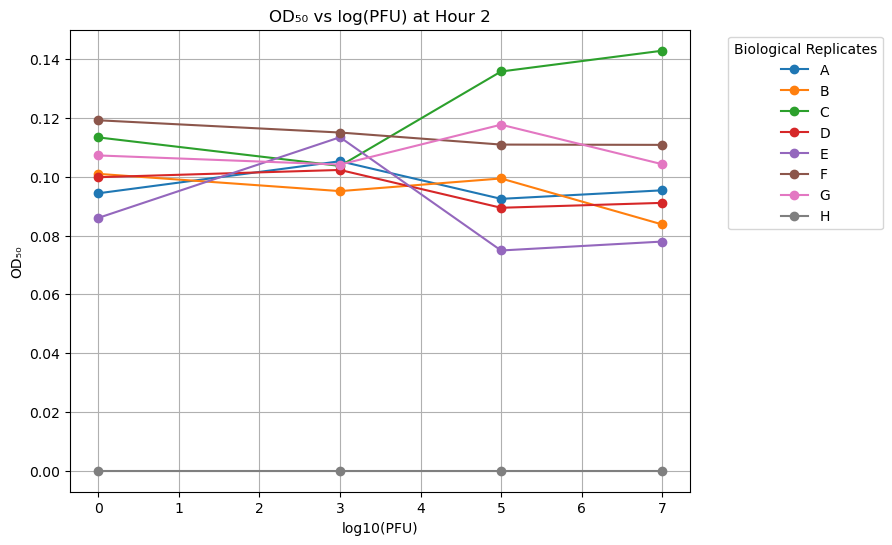

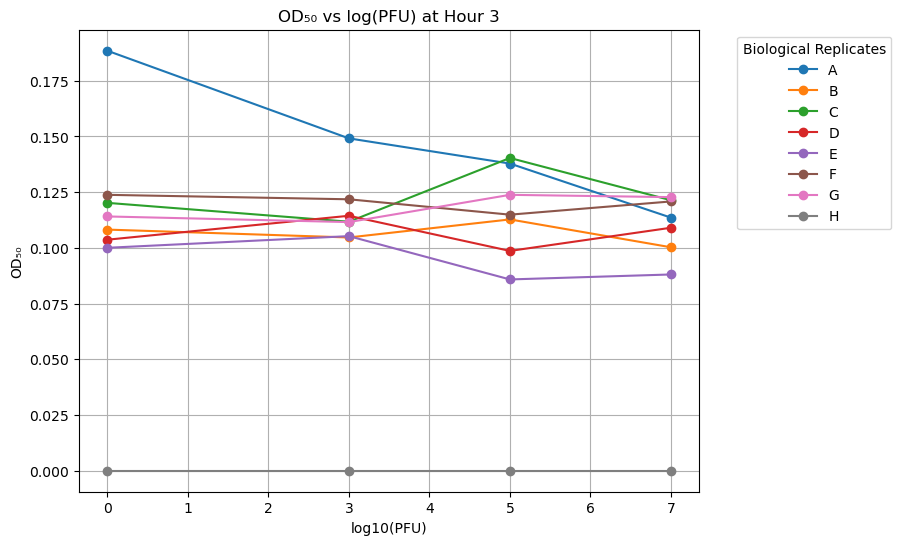

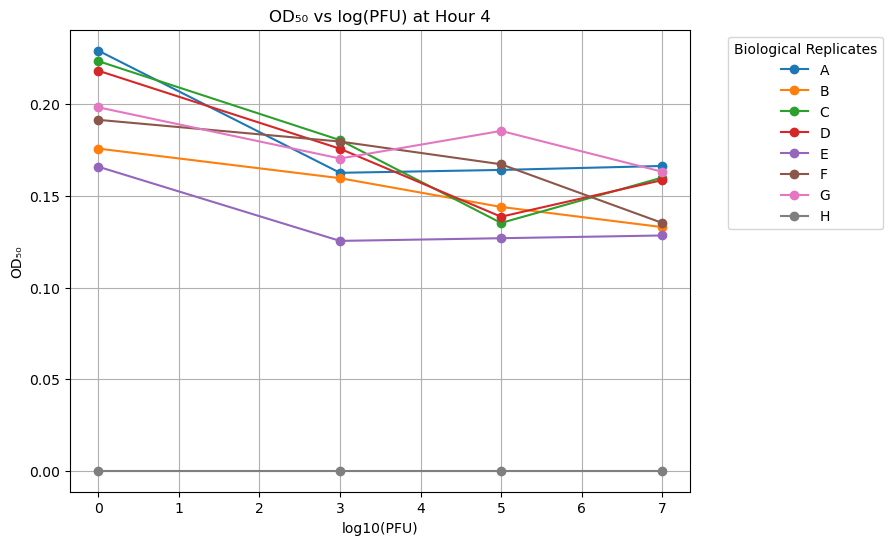

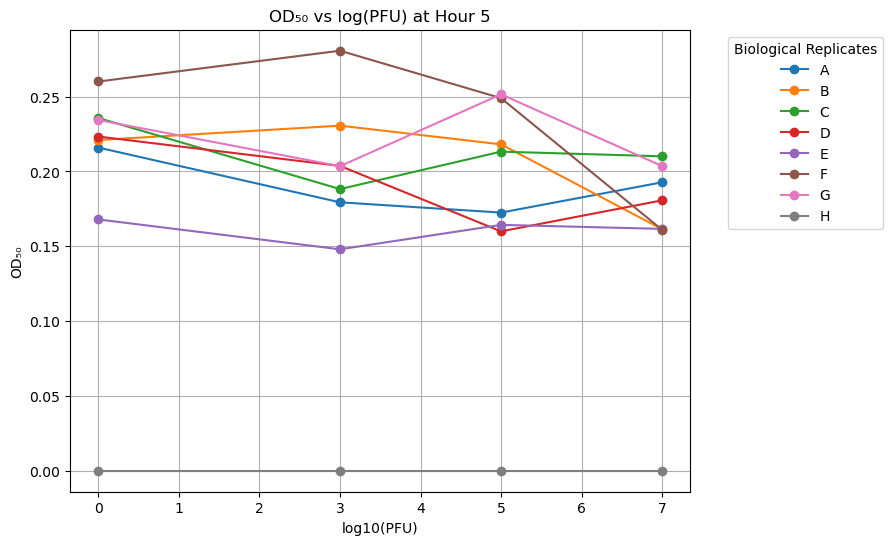

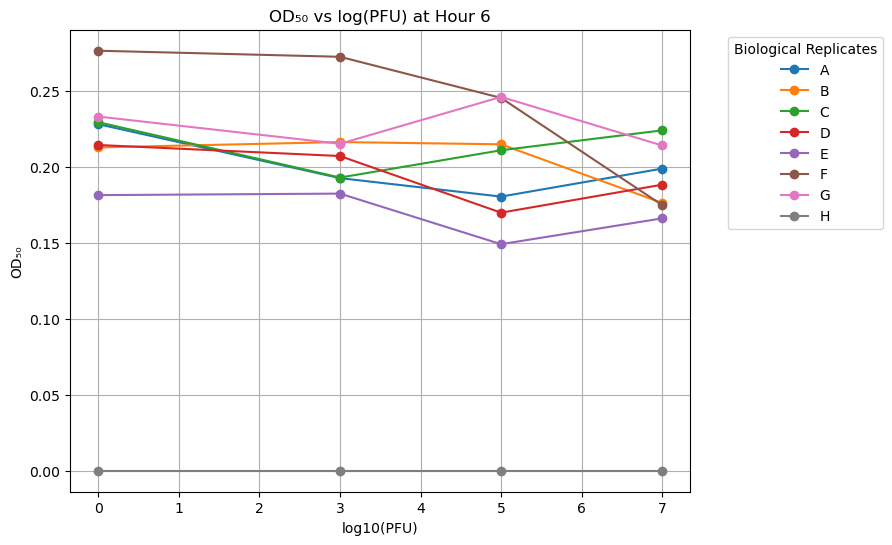

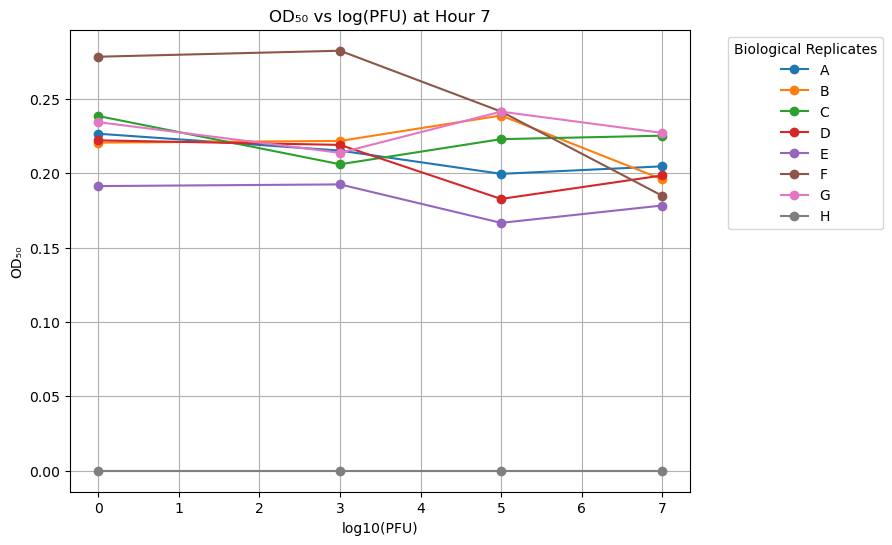

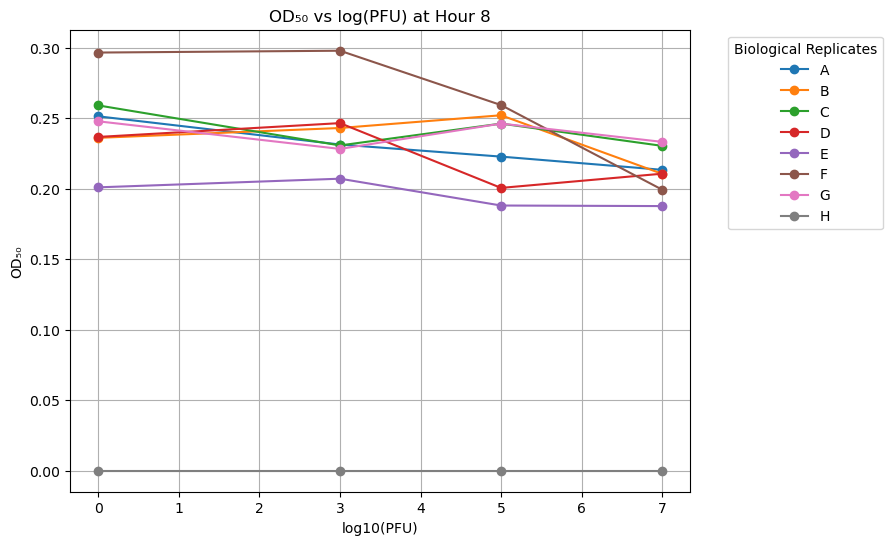

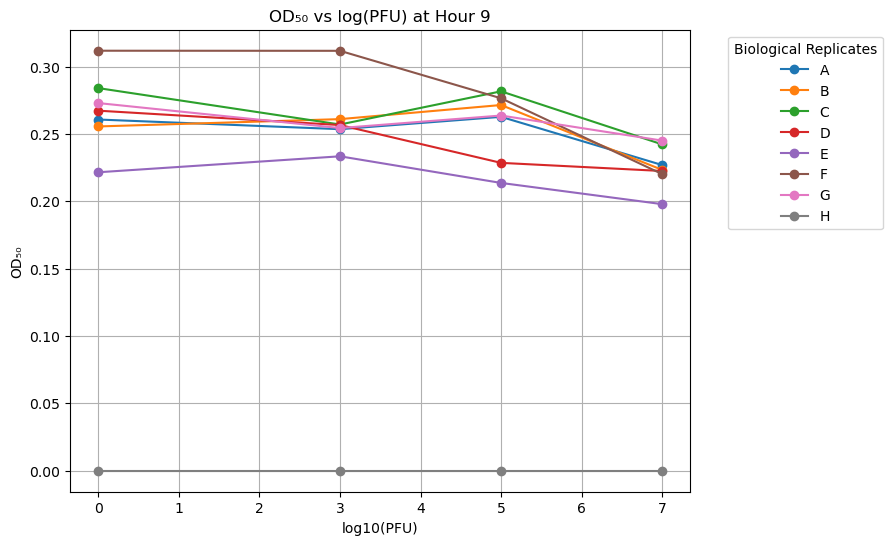

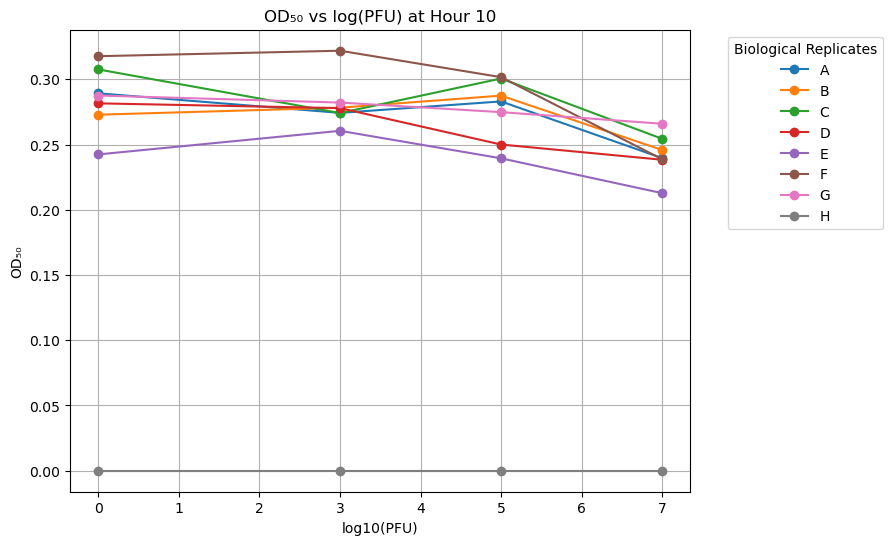

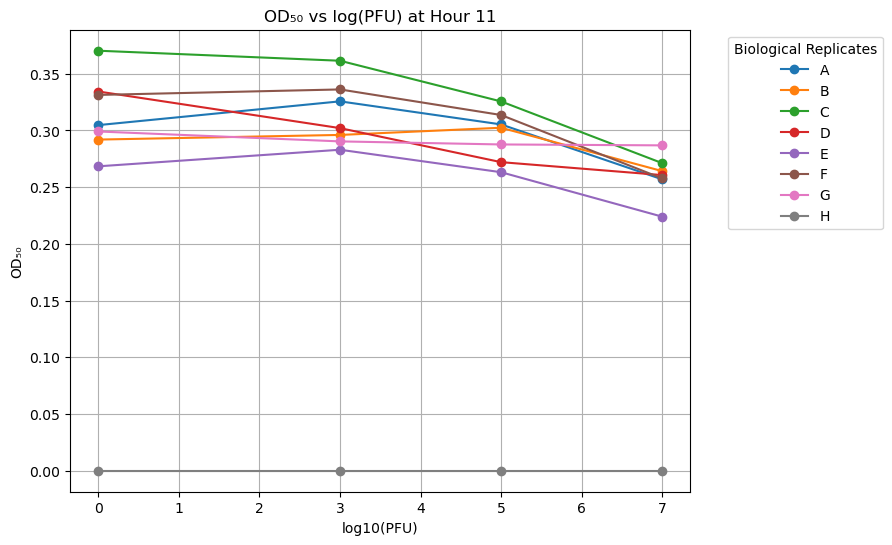

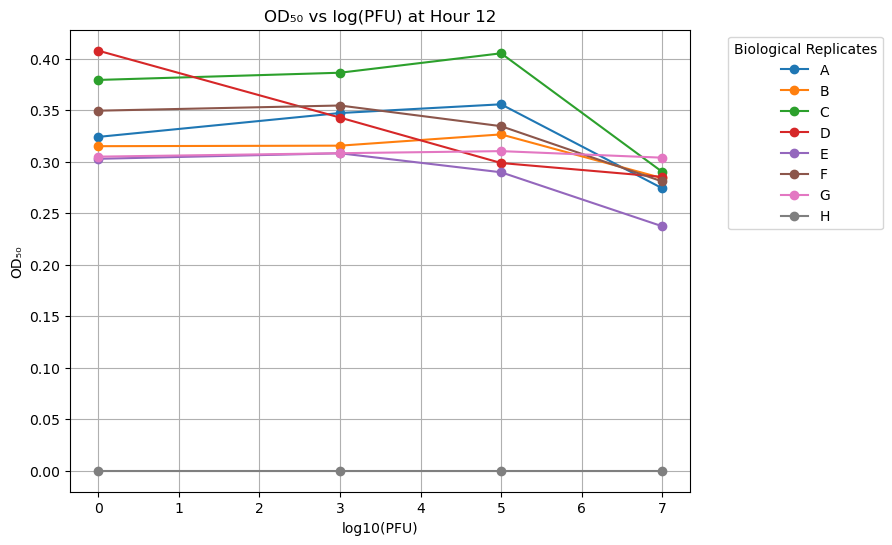

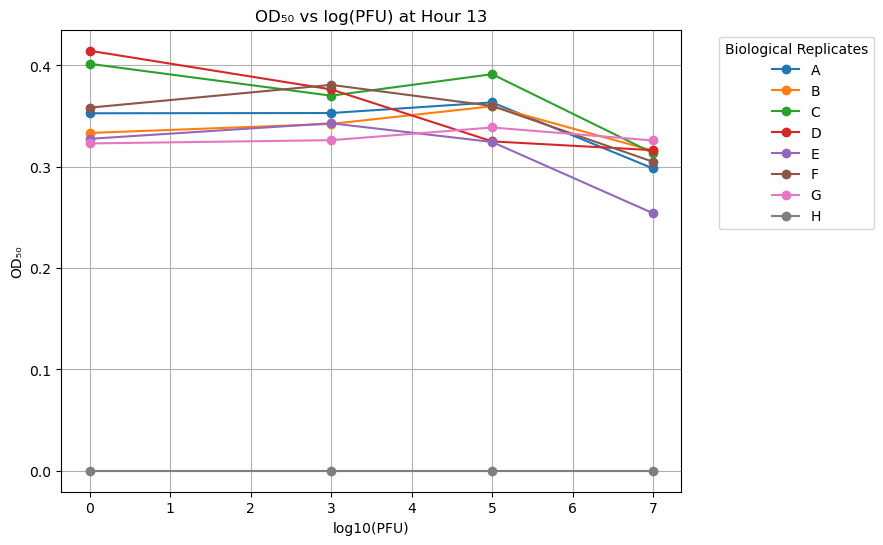

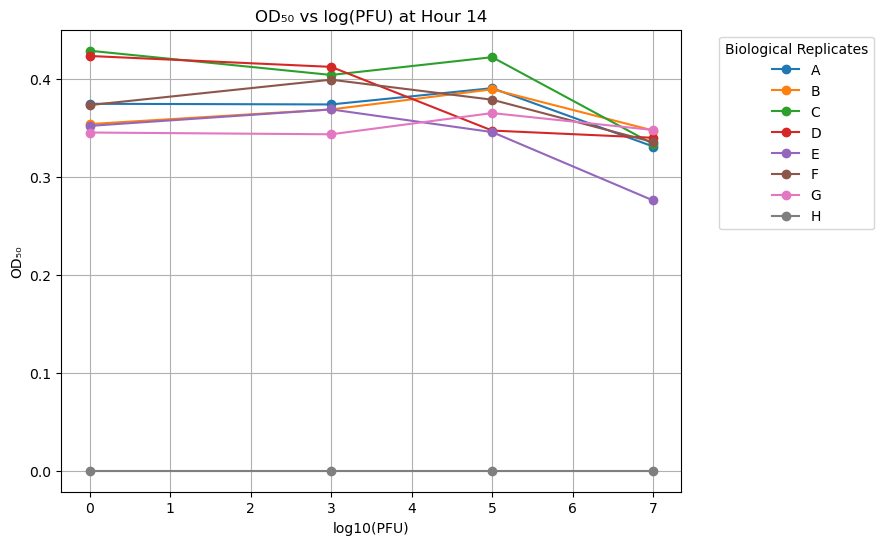

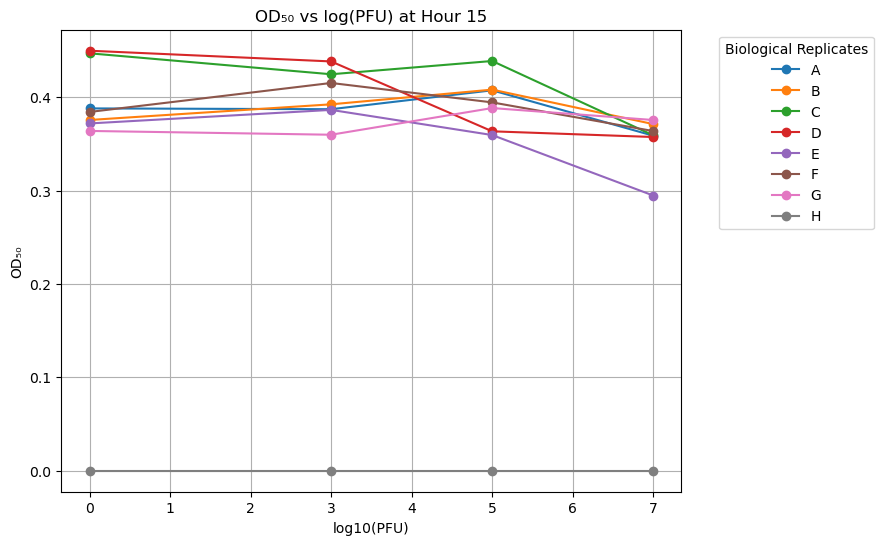

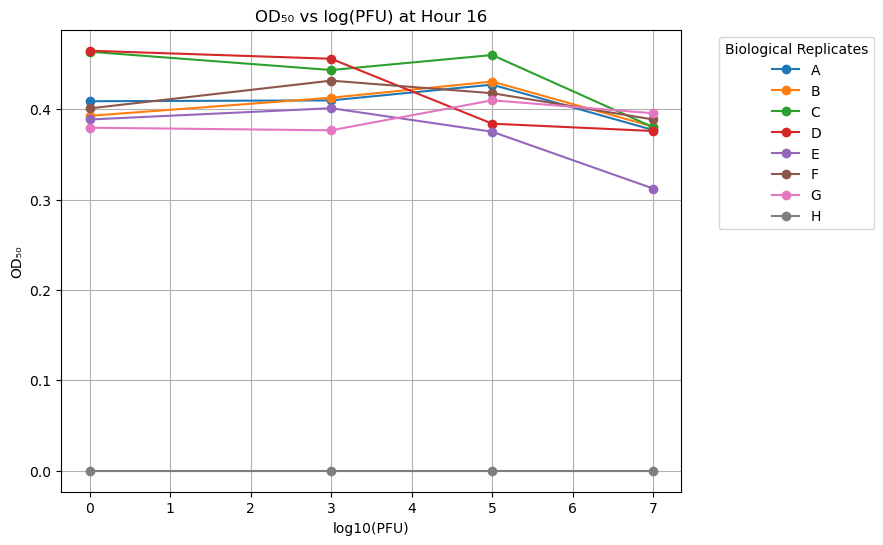

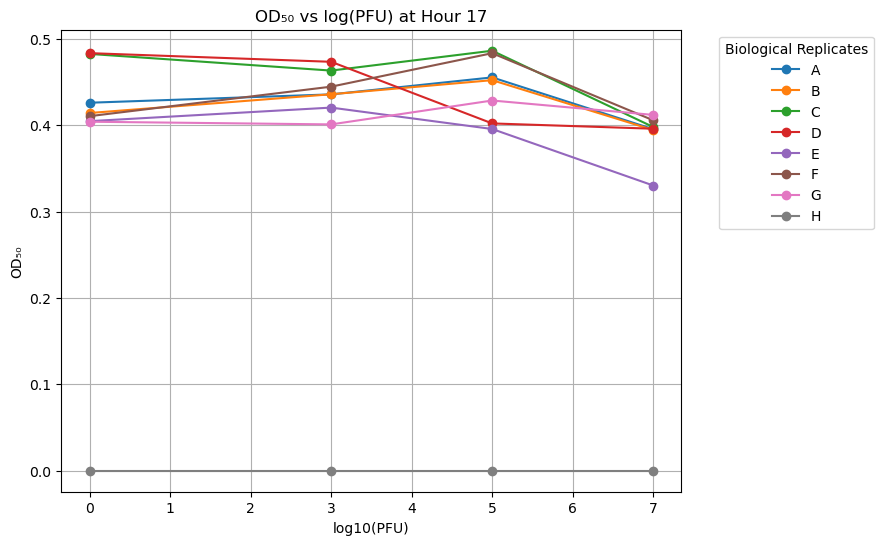

In [8]:
plot_dose_response(df1, pfu_values)

In [11]:
import numpy as np
closest_index = np.abs(df1.index - 12).argmin()

row_48 = df1.iloc[[48]]

df = row_48.copy()

letters = list("ABCDEFGH")

df_avg = pd.DataFrame(index=df.index)

for letter in letters:
    cols = [f"{letter}{i}" for i in range(1, 4)]  # 1–3 only
    df_avg[letter] = df[cols].mean(axis=1)

df_avg = df_avg.drop(columns=["H"])
df_avg.to_csv("99TK_anc_1.csv", index=True)